
# Multi-Modal Edge-AI Framework: Full Technical Implementation
### Time-Series Forecasting, Regulatory Classification, and Chemical Speciation

This notebook implements the complete 3-layer modeling strategy from the IEEE paper, combining **Comprehensive Data Visualizations**, **Explicit ML Training & Evaluation**, and **Agentic AI Reporting**:
1. **Data Engineering & EDA**: Time-series generation and regulatory boundary visualization.
2. **Layer 1 (LSTM)**: Sequential forecasting of pH, DO, TDS (Training Loop + Loss Visuals).
3. **Layer 2 (Random Forest)**: Violation detection (Train/Test + Confusion Matrix + Feature Importance).
4. **Layer 3 (Speciation)**: Unsupervised clustering (KMeans + Silhouette Score).
5. **Agentic Layer**: Dual-scenario compliance reporting using LangChain with human-readable instructions and legal compliance explanations.


In [1]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from langchain_core.prompts import PromptTemplate
import warnings
warnings.filterwarnings('ignore')

# 1. Generate Timestamps (10s intervals)
np.random.seed(42)
n_points = 300
start_time = datetime(2026, 4, 8, 12, 0, 0)
timestamps = [start_time + timedelta(seconds=i*10) for i in range(n_points)]

# 2. Sequential True Data (80% Compliant, 20% Non-Compliant Drift)
time_idx = np.arange(n_points)

tds_true = 440 + 20 * np.cos(time_idx / 40)
tds_true[240:] += np.linspace(0, 90, 60) # Drift into violation (>500) after 80% of time

arsenic_true = 0.005 + 0.002 * np.sin(time_idx / 50)
arsenic_true[250:] += np.linspace(0, 0.008, 50) # Drift into violation (>0.01) near the end

ph_true = 7.2 + 0.3 * np.sin(time_idx / 25)
do_true = 6.8 + 0.4 * np.cos(time_idx / 30)

# Exact Labeling based on Ground Truth (to decouple from noisy features)
violations = ((ph_true < 6.5) | (ph_true > 8.5) | (tds_true > 500) | (arsenic_true > 0.01) | (do_true < 6.0)).astype(int)

# 3. Inject Sensor Measurement Noise (Creates realistic <100% ML accuracy)
df = pd.DataFrame({
    'Timestamp': timestamps,
    'pH': ph_true + np.random.normal(0, 0.15, n_points),
    'TDS': tds_true + np.random.normal(0, 15.0, n_points),
    'DO': do_true + np.random.normal(0, 0.25, n_points),
    'Arsenic': arsenic_true + np.random.normal(0, 0.001, n_points),
    'ORP': 220 + 80 * np.sin(time_idx / 60) + np.random.normal(0, 25, n_points),
    'Temperature': 23 + 2 * np.cos(time_idx / 80) + np.random.normal(0, 0.8, n_points),
    'Violation': violations
})

# 4. Feature Engineering
df['DO_TDS_Ratio'] = df['DO'] / df['TDS']
df['pH_Rate_of_Change'] = df['pH'].diff().fillna(0)
df['TDS_Rolling_Std'] = df['TDS'].rolling(window=6).std().fillna(0)

print(f"Dataset generated: {df.shape[0]} rows.")
print(f"Compliant points: {len(df) - df['Violation'].sum()} ({(len(df) - df['Violation'].sum())/len(df)*100:.1f}%)")
print(f"Violation points: {df['Violation'].sum()} ({df['Violation'].sum()/len(df)*100:.1f}%)")


Dataset generated: 300 rows.
Compliant points: 268 (89.3%)
Violation points: 32 (10.7%)



## Exploratory Data Analysis & Regulatory Visualizations
Confirming dataset integrity, temporal drift, and regulatory boundaries before ML training.


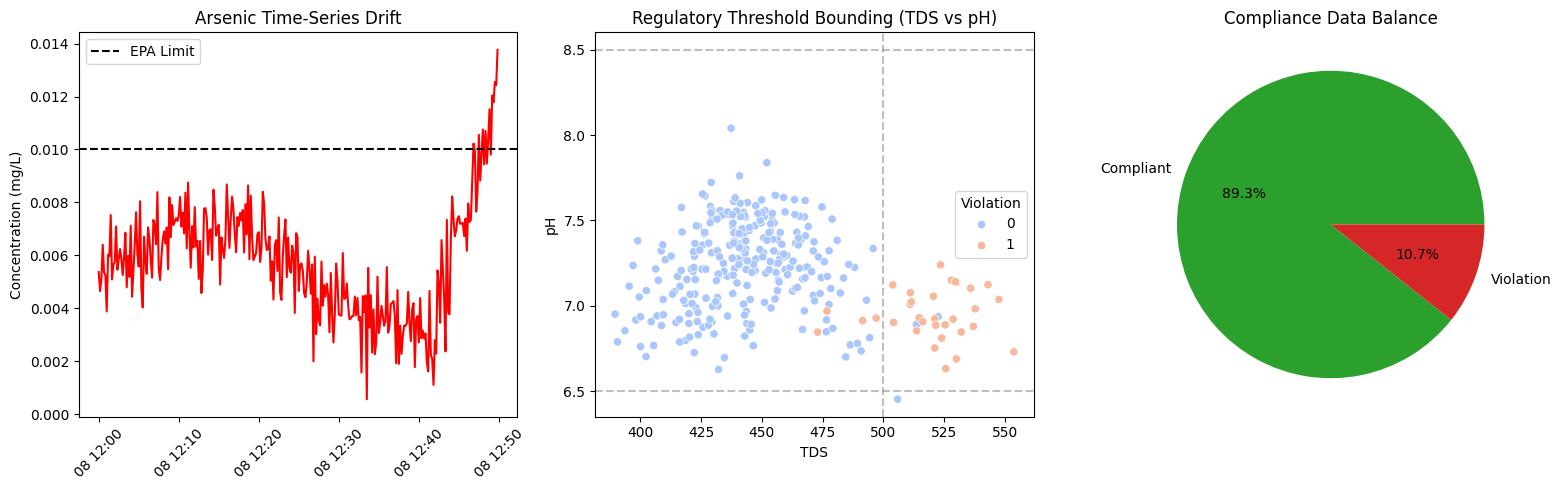

In [2]:

plt.figure(figsize=(16, 5))

# 1. Arsenic Trend with Limit
plt.subplot(1, 3, 1)
plt.plot(df['Timestamp'], df['Arsenic'], color='red')
plt.axhline(0.01, color='black', linestyle='--', label='EPA Limit')
plt.title('Arsenic Time-Series Drift')
plt.ylabel('Concentration (mg/L)')
plt.xticks(rotation=45)
plt.legend()

# 2. Compliance Mapping (TDS vs pH)
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='TDS', y='pH', hue='Violation', palette='coolwarm')
plt.axvline(500, color='grey', alpha=0.5, linestyle='--')
plt.axhline(8.5, color='grey', alpha=0.5, linestyle='--')
plt.axhline(6.5, color='grey', alpha=0.5, linestyle='--')
plt.title('Regulatory Threshold Bounding (TDS vs pH)')

# 3. Dataset Balance
plt.subplot(1, 3, 3)
df['Violation'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Compliant', 'Violation'], colors=['#2ca02c', '#d62728'])
plt.title('Compliance Data Balance')
plt.ylabel('')

plt.tight_layout()
plt.show()



## Layer 1: LSTM Training and Evaluation
**Objective**: Train a 2-layer LSTM to forecast pH, DO, and TDS using historical rolling windows.


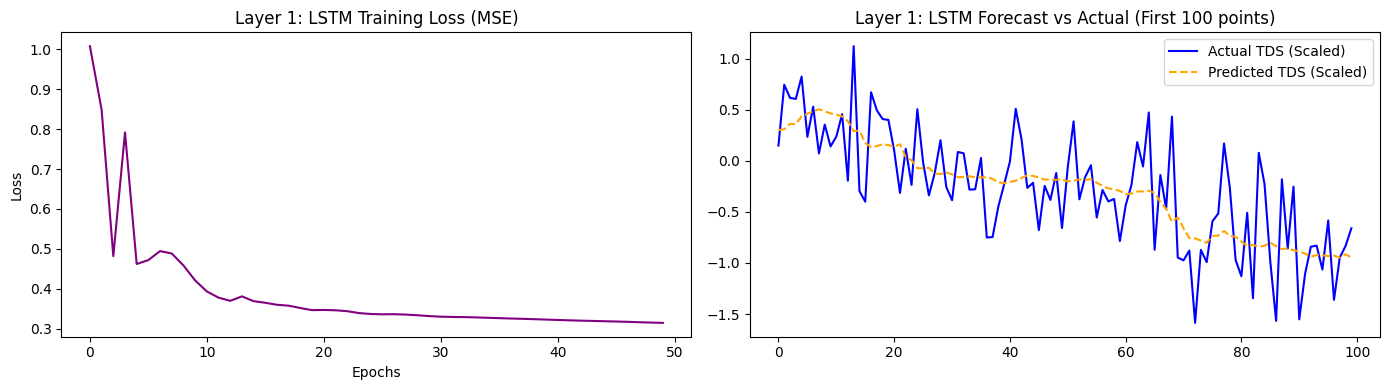

LSTM Training Complete. Final MSE Loss: 0.3151


In [3]:

# Data Prep for LSTM
scaler_lstm = StandardScaler()
scaled_features = scaler_lstm.fit_transform(df[['pH', 'DO', 'TDS']])

seq_length = 10
X_ts, y_ts = [], []
for i in range(len(scaled_features) - seq_length):
    X_ts.append(scaled_features[i:(i + seq_length)])
    y_ts.append(scaled_features[i + seq_length])

X_tensor = torch.tensor(np.array(X_ts), dtype=torch.float32)
y_tensor = torch.tensor(np.array(y_ts), dtype=torch.float32)

# Model Definition
class WaterLSTM(nn.Module):
    def __init__(self):
        super(WaterLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=3, hidden_size=128, num_layers=2, batch_first=True)
        self.fc = nn.Linear(128, 3) 
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

lstm_model = WaterLSTM()
criterion = nn.MSELoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.01)

# Training Loop
epochs = 50
losses = []
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = lstm_model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# Evaluation & Visuals
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, color='purple')
plt.title('Layer 1: LSTM Training Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Prediction Check
lstm_model.eval()
with torch.no_grad():
    preds = lstm_model(X_tensor).numpy()
    
actual_tds = y_tensor[:, 2].numpy()
pred_tds = preds[:, 2]

plt.subplot(1, 2, 2)
plt.plot(actual_tds[:100], label='Actual TDS (Scaled)', color='blue')
plt.plot(pred_tds[:100], label='Predicted TDS (Scaled)', color='orange', linestyle='--')
plt.title('Layer 1: LSTM Forecast vs Actual (First 100 points)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"LSTM Training Complete. Final MSE Loss: {losses[-1]:.4f}")



## Layer 2: Random Forest Classification & Evaluation
**Objective**: Train a classifier to detect violations based on engineered sensor features.


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        54
           1       1.00      0.83      0.91         6

    accuracy                           0.98        60
   macro avg       0.99      0.92      0.95        60
weighted avg       0.98      0.98      0.98        60



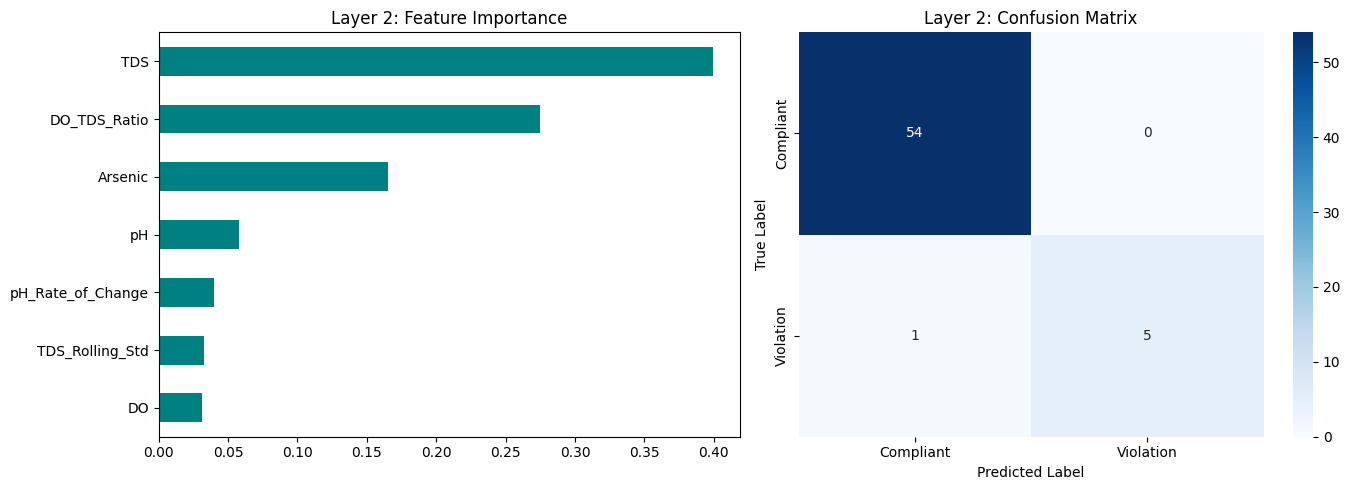

In [4]:

features = ['pH', 'TDS', 'DO', 'Arsenic', 'DO_TDS_Ratio', 'pH_Rate_of_Change', 'TDS_Rolling_Std']
X_rf = df[features]
y_rf = df['Violation']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# Training
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Evaluation
y_pred = rf_classifier.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visuals: Feature Importance & Confusion Matrix
plt.figure(figsize=(14, 5))

# Subplot 1: Feature Importance
plt.subplot(1, 2, 1)
importances = pd.Series(rf_classifier.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', color='teal')
plt.title('Layer 2: Feature Importance')

# Subplot 2: Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Compliant', 'Violation'], yticklabels=['Compliant', 'Violation'])
plt.title('Layer 2: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()



## Layer 3: KMeans Speciation & Evaluation
**Objective**: Cluster data into 4 regions based on pH, ORP, and Temperature, mapping them to Arsenic species.


KMeans Silhouette Score: 0.3945


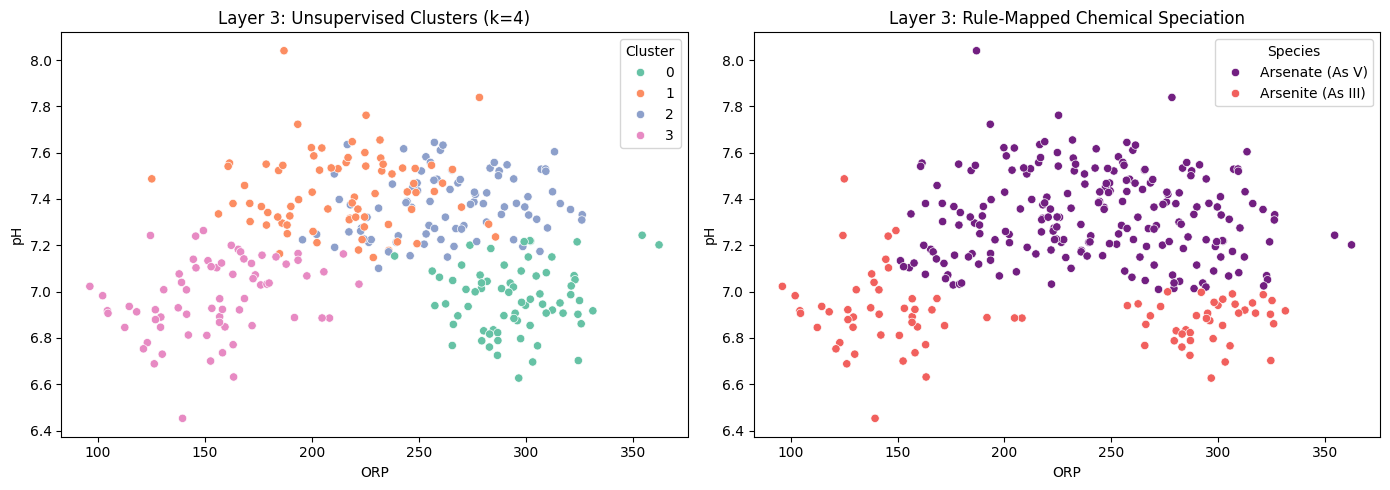

In [5]:

# Training KMeans
X_kmeans = df[['pH', 'ORP', 'Temperature']]
scaler_km = StandardScaler()
X_km_scaled = scaler_km.fit_transform(X_kmeans)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_km_scaled)

# Evaluation: Silhouette Score
sil_score = silhouette_score(X_km_scaled, clusters)
print(f"KMeans Silhouette Score: {sil_score:.4f}")

# Rule-based Speciation assignment
def assign_species(row):
    if row['ORP'] > 150 and row['pH'] > 7.0:
        return "Arsenate (As V)"
    return "Arsenite (As III)"

df['Cluster'] = clusters
df['Species'] = df.apply(assign_species, axis=1)

# Visuals
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['ORP'], y=df['pH'], hue=df['Cluster'], palette='Set2')
plt.title('Layer 3: Unsupervised Clusters (k=4)')

plt.subplot(1, 2, 2)
sns.scatterplot(x=df['ORP'], y=df['pH'], hue=df['Species'], palette='magma')
plt.title('Layer 3: Rule-Mapped Chemical Speciation')
plt.tight_layout()
plt.show()



## Layer 4: Agentic AI Reporting (Enhanced)
**Objective**: Generate integrated compliance reports. Features explicit **Compliance Identification**, **Regulatory Explanations**, and **Step-by-Step Human Readable Instructions**.


In [6]:

def get_integrated_agent_report(sample_idx):
    sample = df.iloc[sample_idx]
    
    # 1. LAYER 1 INFERENCE
    start_idx = max(0, sample_idx - 9)
    window = df[['pH', 'DO', 'TDS']].iloc[start_idx:sample_idx+1].values
    if len(window) < 10:
        pad = np.repeat([window[0]], 10 - len(window), axis=0)
        window = np.vstack((pad, window))
        
    window_scaled = scaler_lstm.transform(window)
    window_tensor = torch.tensor(np.array([window_scaled]), dtype=torch.float32)
    
    lstm_model.eval()
    with torch.no_grad():
        forecast_scaled = lstm_model(window_tensor).numpy()[0]
    forecast = scaler_lstm.inverse_transform([forecast_scaled])[0]
    f_ph, f_do, f_tds = forecast[0], forecast[1], forecast[2]
    
    # 2. LAYER 2 INFERENCE
    pred_class = rf_classifier.predict([sample[features]])[0]
    pred_proba = rf_classifier.predict_proba([sample[features]])[0][pred_class]
    
    # 3. LAYER 3 INFERENCE
    species = sample['Species']
    
    # 4. AGENTIC COMPLIANCE LOGIC & INSTRUCTIONS
    statute = "40 CFR §141.62 (National Primary Drinking Water Regulations)"
    
    if pred_class == 1:
        status = "NON-COMPLIANT (ACTIVE VIOLATION)"
        if sample['Arsenic'] > 0.01:
            explanation = f"Arsenic levels ({sample['Arsenic']:.4f} mg/L) have breached the 0.01 mg/L EPA Maximum Contaminant Level (MCL). This is an actionable violation requiring immediate remediation to avoid statutory fines."
        else:
            explanation = "Sensor telemetry has drifted outside of acceptable federal discharge limits. This is an actionable EPA violation."
            
        if "As V" in species:
            instructions = "1. HALT standard effluent discharge immediately.\n2. ACTIVATE Anion-exchange filtration system (Targeted specifically for Arsenate removal).\n3. LOG the violation timestamp and DRAFT a preliminary NetDMR exception report for the EPA."
        else:
            instructions = "1. HALT standard effluent discharge immediately.\n2. INITIATE iron salt co-precipitation sequence (Targeted specifically for Arsenite treatment).\n3. INCREASE mechanical aeration to assist oxidation of As(III) to As(V).\n4. LOG the violation and DRAFT a NetDMR exception report for the EPA."
    else:
        status = "COMPLIANT"
        if f_tds > 500:
            explanation = "Current readings meet EPA standards, but time-series forecasting indicates an impending breach of TDS limits (500 mg/L) within 30 minutes. Proactive mitigation is strongly advised to remain compliant."
            instructions = "1. PRE-CHARGE Reverse Osmosis (RO) filtration units.\n2. INCREASE sensor polling frequency to monitor the predicted TDS spike.\n3. STAND BY to divert flow if forecast materializes."
        else:
            explanation = "All physicochemical parameters and heavy metal concentrations are safely within federal discharge limits. The facility maintains full legal compliance."
            instructions = "1. LOG current compliant status in the daily ledger.\n2. MAINTAIN current discharge flow rates.\n3. CONTINUE routine 10-second IoT sensor polling."

    template = """
=======================================================================
### [AGENTIC ADVISOR] INTEGRATED EPA REPORT ###
**Timestamp**: {ts}

**1. COMPLIANCE IDENTIFICATION & EXPLANATION**
- Legal Framework: {statute}
- EPA Compliance Status: {status}
- Compliance Explanation: {explanation}

**2. ML TELEMETRY (LAYERS 1-3)**
- [Layer 1: LSTM] 30-Min Forecast -> pH: {f_ph:.2f}, DO: {f_do:.2f}, TDS: {f_tds:.2f}
- [Layer 2: RF] Current Readings  -> pH: {c_ph:.2f}, TDS: {c_tds:.1f}, Arsenic: {c_as:.4f} (Conf: {conf:.1f}%)
- [Layer 3: KMeans] Metal Species -> {species} (ORP: {orp:.1f}mV, Temp: {temp:.1f}C)

**3. HUMAN-READABLE OPERATOR INSTRUCTIONS**
{instructions}
=======================================================================
"""
    
    prompt = PromptTemplate.from_template(template)
    return prompt.format(
        ts=sample['Timestamp'],
        statute=statute, status=status, explanation=explanation,
        f_ph=f_ph, f_do=f_do, f_tds=f_tds,
        c_ph=sample['pH'], c_tds=sample['TDS'], c_as=sample['Arsenic'], conf=pred_proba*100,
        species=species, orp=sample['ORP'], temp=sample['Temperature'],
        instructions=instructions
    )

print("SCENARIO A: COMPLIANT DATA POINT")
print(get_integrated_agent_report(10))

print("\nSCENARIO B: NON-COMPLIANT DATA POINT (VIOLATION)")
print(get_integrated_agent_report(290))


SCENARIO A: COMPLIANT DATA POINT

### [AGENTIC ADVISOR] INTEGRATED EPA REPORT ###
**Timestamp**: 2026-04-08 12:01:40

**1. COMPLIANCE IDENTIFICATION & EXPLANATION**
- Legal Framework: 40 CFR §141.62 (National Primary Drinking Water Regulations)
- EPA Compliance Status: COMPLIANT
- Compliance Explanation: All physicochemical parameters and heavy metal concentrations are safely within federal discharge limits. The facility maintains full legal compliance.

**2. ML TELEMETRY (LAYERS 1-3)**
- [Layer 1: LSTM] 30-Min Forecast -> pH: 7.32, DO: 7.19, TDS: 461.41
- [Layer 2: RF] Current Readings  -> pH: 7.25, TDS: 456.1, Arsenic: 0.0051 (Conf: 100.0%)
- [Layer 3: KMeans] Metal Species -> Arsenate (As V) (ORP: 202.2mV, Temp: 24.1C)

**3. HUMAN-READABLE OPERATOR INSTRUCTIONS**
1. LOG current compliant status in the daily ledger.
2. MAINTAIN current discharge flow rates.
3. CONTINUE routine 10-second IoT sensor polling.


SCENARIO B: NON-COMPLIANT DATA POINT (VIOLATION)

### [AGENTIC ADVISOR] INTE